In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\HP\Downloads\supply_chain_project\data\DataCoSupplyChainDataset.csv', encoding='latin-1')
print("Loaded:", df.shape)
df.head()

Loaded: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [18]:
inventory = df.groupby('Product Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Quantity=('Order Item Quantity', 'sum'),
    Avg_Price=('Order Item Product Price', 'mean'),
    Total_Profit=('Order Profit Per Order', 'sum')
).reset_index().sort_values('Total_Quantity', ascending=False)

print(inventory.head(10))

                                      Product Name   Total_Sales  \
71                Perfect Fitness Perfect Rip Deck  4.421143e+06   
59            Nike Men's Dri-FIT Victory Golf Polo  3.147800e+06   
67                O'Brien Men's Neoprene Life Vest  2.888994e+06   
61               Nike Men's Free 5.0+ Running Shoe  3.667633e+06   
102  Under Armour Girls' Toddler Spine Surge Runni  1.269083e+06   
56         Nike Men's CJ Elite 2 TD Football Cleat  2.891758e+06   
24       Field & Stream Sportsman 16 Gun Fire Safe  6.929654e+06   
70                     Pelican Sunstream 100 Kayak  3.099845e+06   
21   Diamondback Women's Serene Classic Comfort Bi  4.118426e+06   
22                        ENO Atlas Hammock Straps  2.993002e+04   

     Total_Quantity   Avg_Price   Total_Profit  
71            73698   59.990002  493828.299782  
59            62956   50.000000  350421.029567  
67            57803   49.980000  318451.430554  
61            36680   99.989998  379915.818503  
102   

C:\Users\HP\AppData\Local\Temp\ipykernel_27528\2378398172.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_qty['Total_Quantity'], y=top_qty['Product Name'], palette='Reds_r')


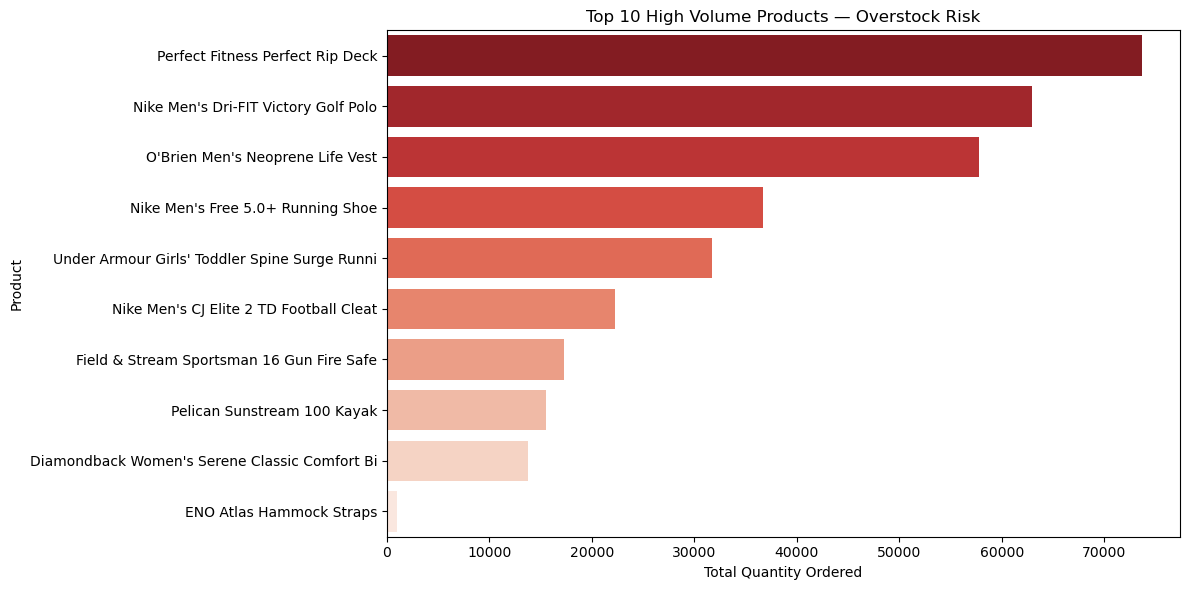

In [19]:
top_qty = inventory.head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_qty['Total_Quantity'], y=top_qty['Product Name'], palette='Reds_r')
plt.title('Top 10 High Volume Products — Overstock Risk')
plt.xlabel('Total Quantity Ordered')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [20]:
# EOQ = sqrt(2 * Demand * Ordering Cost / Holding Cost)
# Assumptions: Ordering cost = 50, Holding cost = 10% of avg price

inventory['Ordering_Cost'] = 50
inventory['Holding_Cost'] = inventory['Avg_Price'] * 0.10
inventory['EOQ'] = np.sqrt(
    (2 * inventory['Total_Quantity'] * inventory['Ordering_Cost']) / 
    inventory['Holding_Cost']
).round(2)

print("EOQ Calculated!")
inventory[['Product Name','Total_Quantity','Avg_Price','EOQ']].head(10)

EOQ Calculated!


,Product Name,Total_Quantity,Avg_Price,EOQ
71,Perfect Fitness Perfect Rip Deck,73698,59.990002,1108.38
59,Nike Men's Dri-FIT Victory Golf Polo,62956,50.000000,1122.11
67,O'Brien Men's Neoprene Life Vest,57803,49.980000,1075.42
61,Nike Men's Free 5.0+ Running Shoe,36680,99.989998,605.67
102,Under Armour Girls' Toddler Spine Surge Runni,31735,39.990002,890.83
56,Nike Men's CJ Elite 2 TD Football Cleat,22246,129.990005,413.69
24,Field & Stream Sportsman 16 Gun Fire Safe,17325,399.980011,208.12
70,Pelican Sunstream 100 Kayak,15500,199.990005,278.40
21,Diamondback Women's Serene Classic Comfort Bi,13729,299.980011,213.93
22,ENO Atlas Hammock Straps,998,29.990000,182.42


In [21]:
# Reorder Point = Average Daily Demand * Lead Time
# Assuming lead time = 3 days

inventory['Daily_Demand'] = (inventory['Total_Quantity'] / 365).round(2)
inventory['Reorder_Point'] = (inventory['Daily_Demand'] * 3).round(2)

print("Reorder Points:")
inventory[['Product Name','Daily_Demand','Reorder_Point','EOQ']].head(10)

Reorder Points:


,Product Name,Daily_Demand,Reorder_Point,EOQ
71,Perfect Fitness Perfect Rip Deck,201.91,605.73,1108.38
59,Nike Men's Dri-FIT Victory Golf Polo,172.48,517.44,1122.11
67,O'Brien Men's Neoprene Life Vest,158.36,475.08,1075.42
61,Nike Men's Free 5.0+ Running Shoe,100.49,301.47,605.67
102,Under Armour Girls' Toddler Spine Surge Runni,86.95,260.85,890.83
56,Nike Men's CJ Elite 2 TD Football Cleat,60.95,182.85,413.69
24,Field & Stream Sportsman 16 Gun Fire Safe,47.47,142.41,208.12
70,Pelican Sunstream 100 Kayak,42.47,127.41,278.40
21,Diamondback Women's Serene Classic Comfort Bi,37.61,112.83,213.93
22,ENO Atlas Hammock Straps,2.73,8.19,182.42


C:\Users\HP\AppData\Local\Temp\ipykernel_27528\450036878.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=low_sales['Total_Sales'].head(10),


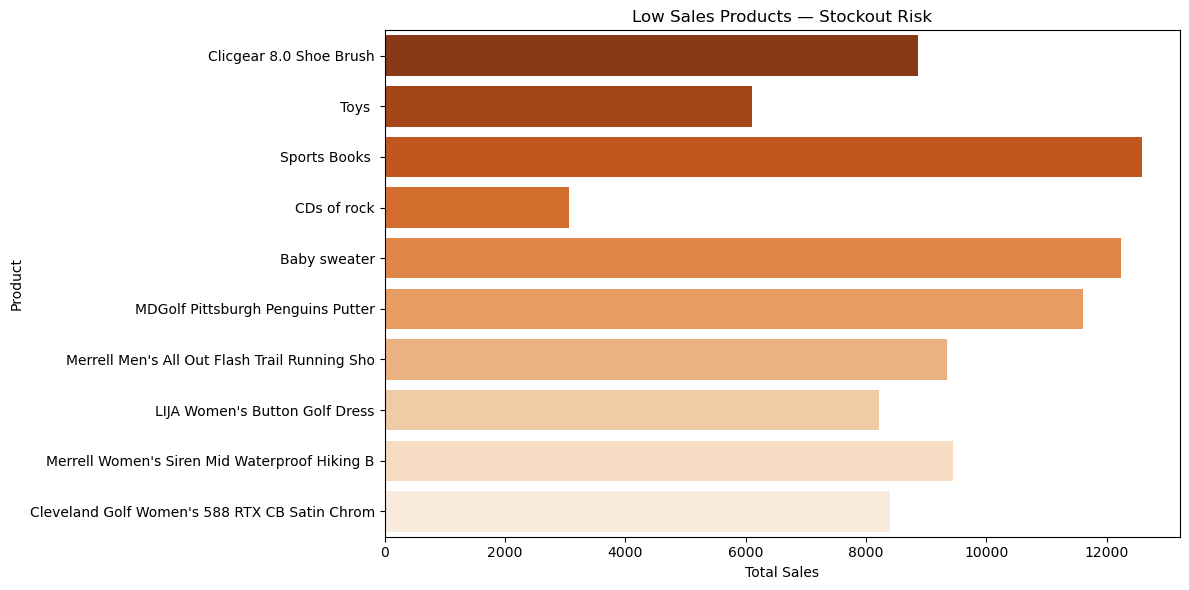

In [22]:
# Products with low sales but high price = stockout risk
low_sales = inventory[inventory['Total_Sales'] < inventory['Total_Sales'].quantile(0.25)]

plt.figure(figsize=(12,6))
sns.barplot(x=low_sales['Total_Sales'].head(10), 
            y=low_sales['Product Name'].head(10), palette='Oranges_r')
plt.title('Low Sales Products — Stockout Risk')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

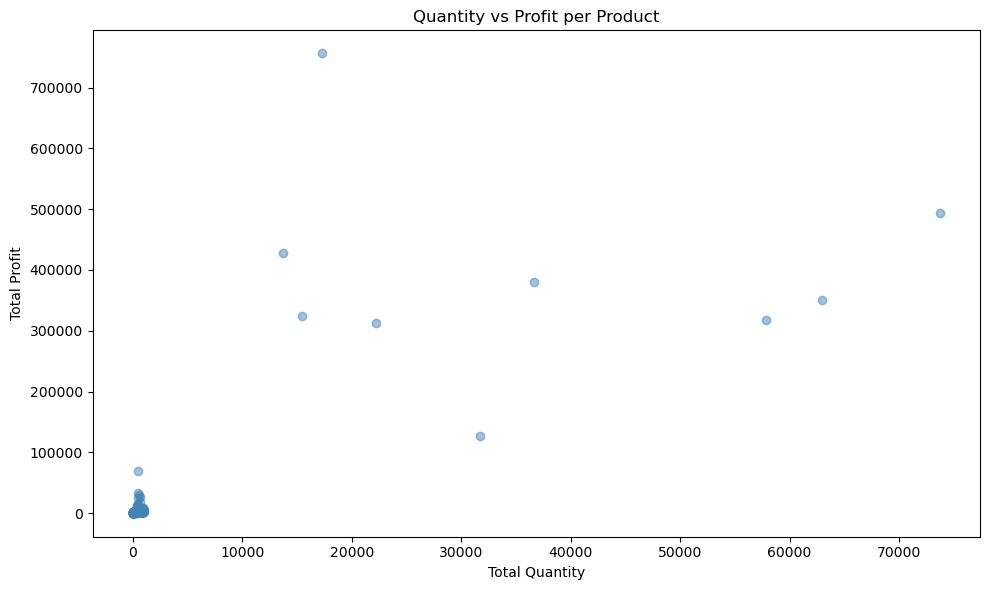

In [23]:
plt.figure(figsize=(10,6))
plt.scatter(inventory['Total_Quantity'], inventory['Total_Profit'], 
            alpha=0.5, color='steelblue')
plt.title('Quantity vs Profit per Product')
plt.xlabel('Total Quantity')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

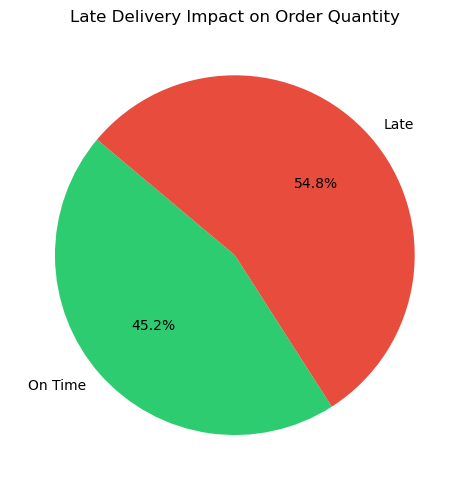

In [24]:
late_impact = df.groupby('Late_delivery_risk')['Order Item Quantity'].sum()

plt.figure(figsize=(6,5))
plt.pie(late_impact.values, labels=['On Time','Late'], 
        autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'], startangle=140)
plt.title('Late Delivery Impact on Order Quantity')
plt.tight_layout()
plt.show()